<a href="https://colab.research.google.com/github/John-588-git/Dashboard/blob/main/Class_Image_Transformation_Utils.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

All packages imported successfully!
Original image created.
Image size: (512, 512, 3)

Forward transformation matrix:
[[  0.8660254    0.5        -53.70250337]
 [ -0.5          0.8660254  192.29749663]]

Forward transformation completed.

3x3 Homogeneous transformation matrix:
[[  0.8660254    0.5        -53.70250337]
 [ -0.5          0.8660254  192.29749663]
 [  0.           0.           1.        ]]

Inverse transformation matrix:
[[   0.8660254    -0.5         142.65648048]
 [   0.5           0.8660254  -139.68326548]
 [   0.            0.            1.        ]]

2x3 inverse affine matrix:
[[   0.8660254    -0.5         142.65648048]
 [   0.5           0.8660254  -139.68326548]]

Inverse transformation completed.


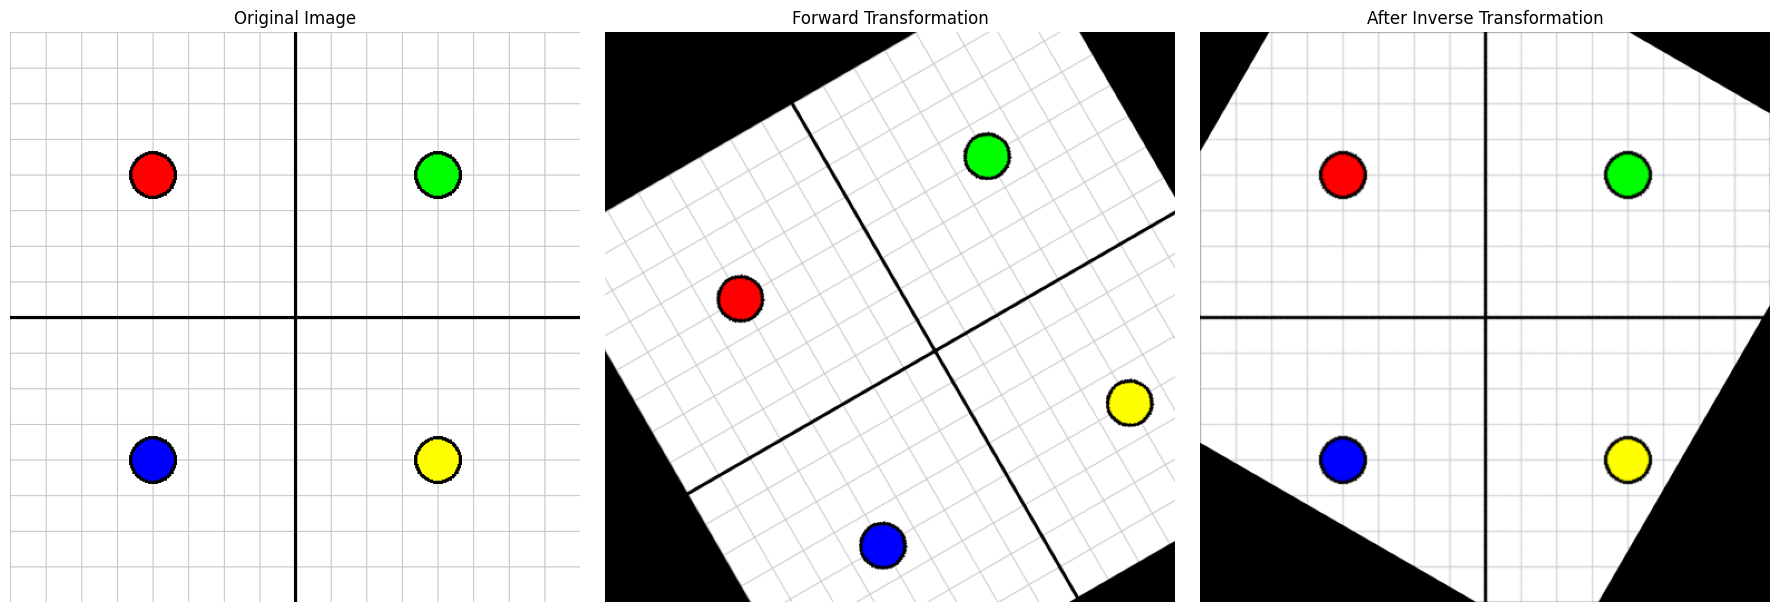

"The process is:\n\nOriginal image → Forward transformation → Transformed image → Inverse transformation → Recovered image\n\nThe forward transformation matrix performs the rotation and translation:\n\n$$ \\mathbf{x'} = \\mathbf{T}\\mathbf{x} $$\n\nThe inverse transformation is obtained by calculating:\n\n$$ \\mathbf{T}^{-1} $$\n\nand applying it to the transformed image:\n\nx=T\n−1\nx\n′"

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("All packages imported successfully!")


class ImageTransformationUtils:
    """Utility class for image transformation operations"""

    @staticmethod
    def create_test_grid(size=512):
        grid = np.ones((size, size, 3), dtype=np.uint8) * 255
        spacing = size // 16

        for i in range(0, size, spacing):
            cv2.line(grid, (i, 0), (i, size), (200, 200, 200), 1)
            cv2.line(grid, (0, i), (size, i), (200, 200, 200), 1)

        # Centre axes
        cv2.line(
            grid,
            (size // 2, 0),
            (size // 2, size),
            (0, 0, 0),
            2
        )

        cv2.line(
            grid,
            (0, size // 2),
            (size, size // 2),
            (0, 0, 0),
            2
        )

        # Colours
        colors = [
            (255, 0, 0),
            (0, 255, 0),
            (0, 0, 255),
            (255, 255, 0)
        ]

        positions = [
            (size // 4, size // 4),
            (3 * size // 4, size // 4),
            (size // 4, 3 * size // 4),
            (3 * size // 4, 3 * size // 4)
        ]

        for (x, y), color in zip(positions, colors):
            cv2.circle(grid, (x, y), 20, color, -1)
            cv2.circle(grid, (x, y), 20, (0, 0, 0), 2)

        return grid

# 1. CREATE ORIGINAL IMAGE

image = ImageTransformationUtils.create_test_grid(512)

print("Original image created.")
print("Image size:", image.shape)
# 2. DEFINE TRANSFORMATION

height, width = image.shape[:2]
# Rotation angle
angle = 30
# Scaling
scale = 1.0
# Centre of rotation
center = (width // 2, height // 2)
# Create 2D rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    angle,
    scale
)
# Add translation
rotation_matrix[0, 2] += 40
rotation_matrix[1, 2] += 30

print("\nForward transformation matrix:")
print(rotation_matrix)
# 3. APPLY FORWARD TRANSFORMATION

transformed_image = cv2.warpAffine(
    image,
    rotation_matrix,
    (width, height)
)

print("\nForward transformation completed.")
# 4. CONVERT 2D MATRIX TO 3x3 HOMOGENEOUS MATRIX
forward_matrix = np.vstack([
    rotation_matrix,
    [0, 0, 1]
])

print("\n3x3 Homogeneous transformation matrix:")
print(forward_matrix)
# 5. CALCULATE INVERSE MATRIX
inverse_matrix = np.linalg.inv(forward_matrix)

print("\nInverse transformation matrix:")
print(inverse_matrix)
# 6. EXTRACT 2x3 MATRIX FOR OPENCV
inverse_affine_matrix = inverse_matrix[:2, :]

print("\n2x3 inverse affine matrix:")
print(inverse_affine_matrix)
# 7. APPLY INVERSE TRANSFORMATION
recovered_image = cv2.warpAffine(
    transformed_image,
    inverse_affine_matrix,
    (width, height)
)

print("\nInverse transformation completed.")
# 8. DISPLAY RESULTS
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(transformed_image)
plt.title("Forward Transformation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recovered_image)
plt.title("After Inverse Transformation")
plt.axis("off")

plt.tight_layout()
plt.show()
"""The process is:

Original image → Forward transformation → Transformed image → Inverse transformation → Recovered image

The forward transformation matrix performs the rotation and translation:

$$ \\mathbf{x'} = \\mathbf{T}\\mathbf{x} $$

The inverse transformation is obtained by calculating:

$$ \\mathbf{T}^{-1} $$

and applying it to the transformed image:

x=T
−1
x
′"""